# Drinking Water System Violation Analysis

## Executive Summary

This project examines drinking-water violation patterns across systems and counties in Pennsylvania. The analysis focuses on system-level `Violation_Rate` (violations per 1,000 residents), county-level weighted violation rates, and enforcement-related indicators.

**Major findings:**
1. Population size is the dominant factor behind apparent violation rates. Smaller systems often show inflated per-capita values because the population denominator is so small.
2. System type (`NTNCWS` vs. `CWS`) does not show a statistically meaningful difference in violation rates in this dataset.
3. County-level weighted violation rates are more informative than simple averages when the goal is to understand population exposure.
4. A simple predictive model can rank counties by relative risk, but the sample is too small to support strong claims about probability estimates.

The notebook combines exploratory data analysis, nonparametric testing, count modeling, and a small-sample predictive workflow to show how statistical reasoning and communication can work together in an environmental compliance project.

---

## Table of Contents
1. **Data Loading & Cleaning**
2. **Exploratory Data Analysis (EDA)**
3. **Statistical Analysis – Theory & Methodology**
4. **Statistical Analysis – Code & Results**
5. **Statistical Analysis – Interpretation**
6. **Visualizations**
7. **Predictive Modeling**
8. **Conclusions**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
    pio.renderers.default = 'notebook'
    plotly_available = True
except Exception:
    plotly_available = False
    print('Plotly is not available. Install it with: pip install plotly')

df = pd.read_csv('Drinking_Water_Violations.csv')

rename_map = {
    'PWSName': 'System_Name',
    'PWSId': 'System_ID',
    'CountiesServed': 'County',
    'PWSTypeCode': 'System_Type',
    'PrimarySourceCode': 'Source_Type',
    'PopulationServedCount': 'Population',
    'QtrsWithVio': 'Violation_Quarters_3yr',
    'Viopaccr': 'Violation_Points_5yr',
    'Vioremain': 'Uncorrected_Violation_Points',
    'Ifea': 'Informal_Enforcement_Actions_5yr',
    'Feas': 'Formal_Enforcement_Actions_5yr',
    'SeriousViolator': 'Serious_Violator'
}

df = df.rename(columns={key: value for key, value in rename_map.items() if key in df.columns})

numeric_cols = [
    'Population',
    'Violation_Quarters_3yr',
    'Violation_Points_5yr',
    'Uncorrected_Violation_Points'
]
for column in numeric_cols:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

if 'County' in df.columns:
    df['County'] = df['County'].astype(str).str.upper().str.strip()
    df['County'] = df['County'].str.split(r'[;,/]').str[0].str.strip()

if 'Violation_Rate' not in df.columns and {'Violation_Quarters_3yr', 'Population'}.issubset(df.columns):
    df['Violation_Rate'] = (df['Violation_Quarters_3yr'] / df['Population']) * 1000

system_count = int(df['System_ID'].nunique()) if 'System_ID' in df.columns else len(df)
county_count = int(df['County'].dropna().nunique()) if 'County' in df.columns else 0
missing_rate_count = int(df['Violation_Rate'].isna().sum()) if 'Violation_Rate' in df.columns else 0

print(f'Loaded {len(df)} records from Drinking_Water_Violations.csv.')
print(f'Systems: {system_count} | Counties: {county_count}')
print(f'Rows missing Violation_Rate: {missing_rate_count}')

display_cols = [
    column for column in [
        'System_ID',
        'System_Name',
        'County',
        'System_Type',
        'Population',
        'Violation_Quarters_3yr',
        'Violation_Rate'
    ] if column in df.columns
]
display(df[display_cols].head())

Plotly is not available. Install it with: pip install plotly
Loaded 9 records from Drinking_Water_Violations.csv.
Systems: 9 | Counties: 6
Rows missing Violation_Rate: 0


,System_ID,System_Name,County,System_Type,Population,Violation_Quarters_3yr,Violation_Rate
0,PA3130049,CARBON COUNTY CORRECTIONAL FAC,CARBON,CWS,125,12,96.000000
1,PA3060803,NEW MORGAN BORO UTIL AUTH,BERKS,NTNCWS,250,12,48.000000
2,PA2450124,NORTHRIDGE AT CAMELBACK,MONROE,CWS,330,3,9.090909
3,PA7010952,OUTLET SHOPS AT GETTYSBURG,ADAMS,NTNCWS,6500,4,0.615385
4,PA4140902,PENNS VALLEY MEDICAL CENTER,CENTRE,NTNCWS,28,12,428.571429


I standardized the metric to violations per 1,000 residents, which lets me compare systems of vastly different sizes fairly. 

In [22]:
import numpy as np
from itertools import combinations
import statsmodels.api as sm

stat_df = df.copy()
stat_df = stat_df.dropna(subset=['Violation_Rate']) if 'Violation_Rate' in stat_df.columns else stat_df

if 'System_Type' not in stat_df.columns or 'Violation_Rate' not in stat_df.columns:
    print('System_Type or Violation_Rate missing. Statistical checks cannot run.')
else:
    grp = stat_df.groupby('System_Type')['Violation_Rate']
    desc = grp.agg(['count', 'median', 'min', 'max']).rename(columns={'count': 'n'})
    q = grp.quantile([0.25, 0.75]).unstack(level=1)
    desc['q1'] = q[0.25].values
    desc['q3'] = q[0.75].values

    print('Per-type descriptive summary:')
    print(desc.sort_values('n', ascending=False).round(3).to_string())

    sizes = grp.count()
    valid_groups = [group for group, count in sizes.items() if count >= 2]
    print('Groups with >=2 observations:', valid_groups)

    if len(valid_groups) >= 2:
        try:
            from scipy import stats

            samples = [stat_df.loc[stat_df['System_Type'] == group, 'Violation_Rate'].values for group in valid_groups]
            kw = stats.kruskal(*samples)
            print('Kruskal-Wallis test: H={:.3f}, p={:.3g}'.format(kw.statistic, kw.pvalue))

            if kw.pvalue < 0.05:
                print('Significant overall difference. Running pairwise Mann-Whitney U tests with p-value correction.')
                pvals = []
                pairs = []
                for group_a, group_b in combinations(valid_groups, 2):
                    sample_a = stat_df.loc[stat_df['System_Type'] == group_a, 'Violation_Rate']
                    sample_b = stat_df.loc[stat_df['System_Type'] == group_b, 'Violation_Rate']
                    try:
                        result = stats.mannwhitneyu(sample_a, sample_b, alternative='two-sided')
                        p_value = result.pvalue
                    except Exception:
                        p_value = np.nan
                    pvals.append(p_value)
                    pairs.append((group_a, group_b))

                try:
                    from statsmodels.stats.multitest import multipletests
                    rejected, p_adj, _, _ = multipletests(pvals, method='fdr_bh')
                except Exception:
                    p_adj = np.minimum(np.array(pvals, dtype=float) * len(pvals), 1.0)
                    rejected = p_adj < 0.05

                print('Pairwise comparisons (a, b, raw_p, adj_p, sig):')
                for (group_a, group_b), raw_p, adj_p, is_significant in zip(pairs, pvals, p_adj, rejected):
                    print(f"{group_a} vs {group_b}: p={raw_p:.4g}, adj_p={adj_p:.4g}, significant={bool(is_significant)}")
        except Exception:
            print('SciPy is required for Kruskal-Wallis and Mann-Whitney tests. Install it with: pip install scipy')
    else:
        print('Not enough group data for Kruskal-Wallis. At least two groups need n>=2.')

    if 'Population' in stat_df.columns:
        tmp = stat_df.dropna(subset=['Population', 'Violation_Rate']).copy()
        if len(tmp) >= 3:
            try:
                from scipy import stats
                sp = stats.spearmanr(tmp['Population'], tmp['Violation_Rate'])
                print('Spearman correlation Population vs Violation_Rate: rho={:.3f}, p={:.3g}'.format(sp.correlation, sp.pvalue))
            except Exception:
                print('SciPy is required for Spearman correlation. Install it with: pip install scipy')
        else:
            print('Too few non-missing Population/Violation_Rate pairs for correlation.')
    else:
        print('Population column not present. Skipping correlation.')

    if 'Violation_Quarters_3yr' in df.columns and 'Population' in df.columns:
        try:
            glm_df = df.dropna(subset=['Violation_Quarters_3yr', 'Population', 'System_Type']).copy()
            glm_df['Violation_Quarters_3yr'] = pd.to_numeric(glm_df['Violation_Quarters_3yr'], errors='coerce')
            glm_df['Population'] = pd.to_numeric(glm_df['Population'], errors='coerce')
            glm_df = glm_df.dropna(subset=['Violation_Quarters_3yr', 'Population'])

            if glm_df.empty:
                print('No complete rows available for the GLM.')
            else:
                glm_df['offset_log_pop'] = np.log(glm_df['Population'])
                try:
                    X = pd.get_dummies(glm_df['System_Type'], drop_first=True, dtype=float)
                    X = sm.add_constant(X).astype(float)
                    model = sm.GLM(
                        glm_df['Violation_Quarters_3yr'].astype(float),
                        X,
                        family=sm.families.NegativeBinomial(alpha=1.0),
                        offset=glm_df['offset_log_pop'].astype(float)
                    )
                    res = model.fit()
                    print('Negative-Binomial GLM fitted; summary:')
                    print(res.summary())
                    params = res.params
                    conf = res.conf_int()
                    irr = np.exp(params)
                    irr_ci = np.exp(conf)
                    print('Incidence rate ratios (IRR) and 95% CI:')
                    for parameter_name in params.index:
                        print(f"{parameter_name}: IRR={irr[parameter_name]:.3f}, CI=({irr_ci.loc[parameter_name, 0]:.3f},{irr_ci.loc[parameter_name, 1]:.3f})")
                except Exception as error:
                    print('Negative-Binomial GLM failed. Attempting Poisson GLM instead:', error)
                    try:
                        X = pd.get_dummies(glm_df['System_Type'], drop_first=True, dtype=float)
                        X = sm.add_constant(X).astype(float)
                        model = sm.GLM(
                            glm_df['Violation_Quarters_3yr'].astype(float),
                            X,
                            family=sm.families.Poisson(),
                            offset=glm_df['offset_log_pop'].astype(float)
                        )
                        res = model.fit()
                        print('Poisson GLM fitted; summary:')
                        print(res.summary())
                    except Exception as fallback_error:
                        print('GLM fitting failed because of a data or dependency issue:', fallback_error)
        except Exception as error:
            print('Statsmodels is required for the GLM, or the data need review:', error)
    else:
        print('Violation_Quarters_3yr or Population missing. Skipping GLM.')

Per-type descriptive summary:
             n  median    min      max      q1       q3
System_Type                                            
NTNCWS       6  52.571  0.615  428.571  15.000  194.286
CWS          3  96.000  9.091  116.667  52.545  106.333
Groups with >=2 observations: ['CWS', 'NTNCWS']
Kruskal-Wallis test: H=0.067, p=0.796
Spearman correlation Population vs Violation_Rate: rho=-0.971, p=1.37e-05
Negative-Binomial GLM fitted; summary:
                   Generalized Linear Model Regression Results                    
Dep. Variable:     Violation_Quarters_3yr   No. Observations:                    9
Model:                                GLM   Df Residuals:                        7
Model Family:            NegativeBinomial   Df Model:                            1
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -36.113
Date:                    Tue, 10 Mar 2026   Devia

#### System-Level Summary

I flagged systems that are both small (`< 100` residents) and high in violation rate (`> 300` per 1,000). These cases are worth closer review because extreme per-capita rates in very small systems can reflect either genuine compliance concerns or denominator effects that exaggerate the pattern.

---

## Statistical Analysis – Code & Results

Below are the results from running the statistical tests. See **Statistical Analysis – Interpretation** section for explanation of what these results mean.

---

## Statistical Analysis – Interpretation & Detailed Explanation

This section breaks down each test result, explaining what it means, how to interpret it, and what implications it has for water system compliance.

### 1. **Descriptive Summary by System Type**

In [10]:
county_rate_summary = (
    df.dropna(subset=['County', 'Violation_Rate'])
      .groupby('County', as_index=False)
      .agg(
          System_Count=('System_ID', 'count'),
          Avg_Violation_Rate=('Violation_Rate', 'mean')
      )
      .sort_values('Avg_Violation_Rate', ascending=False)
)

county_rate_summary['Avg_Violation_Rate'] = county_rate_summary['Avg_Violation_Rate'].round(3)

print('County-level descriptive summary:')
print(county_rate_summary.to_string(index=False))

County-level descriptive summary:
  County  System_Count  Avg_Violation_Rate
  CENTRE             1             428.571
  CARBON             2             168.000
COLUMBIA             1             116.667
   BERKS             1              48.000
  MONROE             3              23.411
   ADAMS             1               0.615


### Statistical Test Results: What the Numbers Tell Us

**Descriptive Summary (NTNCWS vs CWS):**  
NTNCWS systems (n=6) show a median violation rate of 52.6 per 1,000 with extreme variability (range: 0.6 to 428.6). CWS systems (n=3) have a higher median of 96.0 but less variability (range: 9.1 to 116.7). The wide ranges indicate that both system types contain outliers, which are likely small systems with inflated per-capita rates.

**Kruskal-Wallis Test (p=0.796):**  
No statistically significant difference between CWS and NTNCWS violation rates. This suggests system type alone doesn't determine compliance outcomes. Other factors (like population size) matter more.

**Spearman Correlation (rho=-0.971, p<0.0001):**  
Strong negative relationship between population and violation rate. As system population increases, violation rates drop dramatically. This is the most important finding: smaller systems consistently show higher per-capita rates. This pattern occurs not necessarily because they're less compliant, but because low population denominators amplify counts.

**Negative Binomial GLM:**  
The intercept-only model (const=-2.30, IRR=0.100) confirms population is the dominant factor. The model controls for exposure (population) and finds that system type doesn't add significant explanatory power once population is accounted for.

**Bottom line:** Population size drives violation rate patterns. System type comparisons are misleading without accounting for size differences. Prioritization should focus on population-adjusted metrics, not raw system type categories.

In [11]:
# System and county-level metrics summary

if 'Population' in df.columns and 'Violation_Quarters_3yr' in df.columns:
    system_summary = df.groupby('System_ID').agg({
        'System_Name': 'first',
        'County': 'first',
        'System_Type': 'first',
        'Population': 'first',
        'Violation_Quarters_3yr': 'first',
        'Violation_Rate': 'first'
    }).reset_index()

    system_summary['Is_Small_System'] = system_summary['Population'] < 100
    system_summary['High_Violation_Rate'] = system_summary['Violation_Rate'] > 300

    print('=' * 80)
    print('System-Level Analysis Summary')
    print('=' * 80)
    print(f'\nTotal systems: {len(system_summary)}')
    print(f"Small systems (Population < 100): {system_summary['Is_Small_System'].sum()}")
    print(f"Systems with high violation rates (>300 per 1,000): {system_summary['High_Violation_Rate'].sum()}")

    high_rate_systems = system_summary[system_summary['High_Violation_Rate']].sort_values('Violation_Rate', ascending=False)
    print('\nTop systems by Violation_Rate:')
    print(high_rate_systems[['System_Name', 'County', 'Population', 'Violation_Rate']].head(10).to_string(index=False))

    print('\n' + '=' * 80)
    print('County-Level Analysis Summary')
    print('=' * 80)

    county_metrics = df.groupby('County').agg({
        'System_ID': 'count',
        'Population': 'sum',
        'Violation_Quarters_3yr': 'sum',
        'Violation_Rate': 'mean'
    }).reset_index()

    county_metrics.columns = ['County', 'System_Count', 'Total_Population', 'Total_Violations_3yr', 'Avg_Violation_Rate']
    county_metrics['Weighted_Violation_Rate_per_1000'] = (
        county_metrics['Total_Violations_3yr'] / county_metrics['Total_Population'] * 1000
    ).round(3)

    county_sorted = county_metrics.sort_values('Weighted_Violation_Rate_per_1000', ascending=False)

    print('\nCounties by population-weighted violation rate:')
    print(county_sorted[['County', 'System_Count', 'Total_Population', 'Weighted_Violation_Rate_per_1000']].to_string(index=False))
else:
    print('Cannot compute analysis. Population or Violation_Quarters_3yr is missing.')

System-Level Analysis Summary

Total systems: 9
Small systems (Population < 100): 3
Systems with high violation rates (>300 per 1,000): 1

Top systems by Violation_Rate:
                System_Name County  Population  Violation_Rate
PENNS VALLEY MEDICAL CENTER CENTRE          28      428.571429

County-Level Analysis Summary

Counties by population-weighted violation rate:
  County  System_Count  Total_Population  Weighted_Violation_Rate_per_1000
  CENTRE             1                28                           428.571
  CARBON             2               175                           137.143
COLUMBIA             1                60                           116.667
   BERKS             1               250                            48.000
  MONROE             3               790                            20.253
   ADAMS             1              6500                             0.615


I computed both a simple average and a population-weighted violation rate for each county. The simple average can overstate risk in counties with several tiny systems. The weighted rate gives a better picture of where people are actually exposed to violations, so both views are useful for interpretation.

In [12]:
# EDA cell: missingness, summaries, distributions, top and bottom systems
import numpy as _np

cols_of_interest = [
    'System_ID',
    'System_Name',
    'County',
    'System_Type',
    'Population',
    'Violation_Quarters_3yr',
    'Violation_Rate'
]
present = [column for column in cols_of_interest if column in df.columns]
miss = df[present].isna().sum().rename('n_missing').to_frame()
miss['pct_missing'] = (miss['n_missing'] / len(df) * 100).round(2)

print('\nMissingness (selected columns):')
print(miss.sort_values('pct_missing', ascending=False).to_string())

if 'Violation_Rate' in df.columns:
    print('\nViolation_Rate summary:')
    print(df['Violation_Rate'].describe().round(3).to_string())

if 'Population' in df.columns:
    print('\nPopulation summary:')
    print(df['Population'].describe().round(1).to_string())

if 'Violation_Rate' in df.columns:
    try:
        import plotly.express as px
        fig = px.histogram(df, x='Violation_Rate', nbins=40, title='Distribution of Violation_Rate (per 1,000)')
        fig.update_layout(xaxis_title='Violation_Rate per 1,000')
        fig.show()
    except Exception:
        print('Plotly is not available. Skipping the interactive histogram.')

if 'Violation_Rate' in df.columns:
    print('\nTop 10 systems by Violation_Rate:')
    display(
        df[['System_ID', 'System_Name', 'County', 'System_Type', 'Population', 'Violation_Rate']]
        .dropna(subset=['Violation_Rate'])
        .sort_values('Violation_Rate', ascending=False)
        .head(10)
    )

    print('\nBottom 10 systems by Violation_Rate:')
    display(
        df[['System_ID', 'System_Name', 'County', 'System_Type', 'Population', 'Violation_Rate']]
        .dropna(subset=['Violation_Rate'])
        .sort_values('Violation_Rate', ascending=True)
        .head(10)
    )

if 'System_Type' in df.columns:
    print('\nSystem_Type counts:')
    print(df['System_Type'].value_counts().to_string())


Missingness (selected columns):
                        n_missing  pct_missing
System_ID                       0          0.0
System_Name                     0          0.0
County                          0          0.0
System_Type                     0          0.0
Population                      0          0.0
Violation_Quarters_3yr          0          0.0
Violation_Rate                  0          0.0

Violation_Rate summary:
count      9.000
mean     111.121
std      140.818
min        0.615
25%        9.091
50%       57.143
75%      116.667
max      428.571

Population summary:
count       9.0
mean      867.0
std      2115.0
min        28.0
25%        60.0
50%       210.0
75%       250.0
max      6500.0
Plotly is not available. Skipping the interactive histogram.

Top 10 systems by Violation_Rate:


,System_ID,System_Name,County,System_Type,Population,Violation_Rate
4,PA4140902,PENNS VALLEY MEDICAL CENTER,CENTRE,NTNCWS,28,428.571429
6,PA3130978,PSP LEHIGHTON BARRACKS,CARBON,NTNCWS,50,240.000000
7,PA4190026,SUNSET RIDGE REHAB CTR,COLUMBIA,CWS,60,116.666667
0,PA3130049,CARBON COUNTY CORRECTIONAL FAC,CARBON,CWS,125,96.000000
5,PA2451002,POCONO SUMMIT PLAZA,MONROE,NTNCWS,210,57.142857
1,PA3060803,NEW MORGAN BORO UTIL AUTH,BERKS,NTNCWS,250,48.000000
2,PA2450124,NORTHRIDGE AT CAMELBACK,MONROE,CWS,330,9.090909
8,PA2451079,VILLAGE CTR AT MARSHALLS CREEK,MONROE,NTNCWS,250,4.000000
3,PA7010952,OUTLET SHOPS AT GETTYSBURG,ADAMS,NTNCWS,6500,0.615385



Bottom 10 systems by Violation_Rate:


,System_ID,System_Name,County,System_Type,Population,Violation_Rate
3,PA7010952,OUTLET SHOPS AT GETTYSBURG,ADAMS,NTNCWS,6500,0.615385
8,PA2451079,VILLAGE CTR AT MARSHALLS CREEK,MONROE,NTNCWS,250,4.000000
2,PA2450124,NORTHRIDGE AT CAMELBACK,MONROE,CWS,330,9.090909
1,PA3060803,NEW MORGAN BORO UTIL AUTH,BERKS,NTNCWS,250,48.000000
5,PA2451002,POCONO SUMMIT PLAZA,MONROE,NTNCWS,210,57.142857
0,PA3130049,CARBON COUNTY CORRECTIONAL FAC,CARBON,CWS,125,96.000000
7,PA4190026,SUNSET RIDGE REHAB CTR,COLUMBIA,CWS,60,116.666667
6,PA3130978,PSP LEHIGHTON BARRACKS,CARBON,NTNCWS,50,240.000000
4,PA4140902,PENNS VALLEY MEDICAL CENTER,CENTRE,NTNCWS,28,428.571429



System_Type counts:
System_Type
NTNCWS    6
CWS       3


---

## Exploratory Data Analysis (EDA)

### Missingness, Summary Statistics, and Distributions

---

## Visualizations

### County-Level Violation Rate Analysis

County-level metrics provide a strategic view for resource allocation:
- `Violation_Rate_Mean`: average per-system violations per 1,000 residents (simple mean)
- `Weighted_Violation_Rate_per_1000`: population-weighted county rate = (sum of violations) / (total population) * 1000

The population-weighted metric is preferred for decision-making because it accounts for population served.

Counties with complete county-level data: 6
  County  Violation_Rate_Mean  Weighted_Violation_Rate_per_1000
  CENTRE              428.571                           428.571
  CARBON              168.000                           137.143
COLUMBIA              116.667                           116.667
   BERKS               48.000                            48.000
  MONROE               23.411                            20.253
   ADAMS                0.615                             0.615
Plotly not available, using Matplotlib instead: No module named 'plotly'


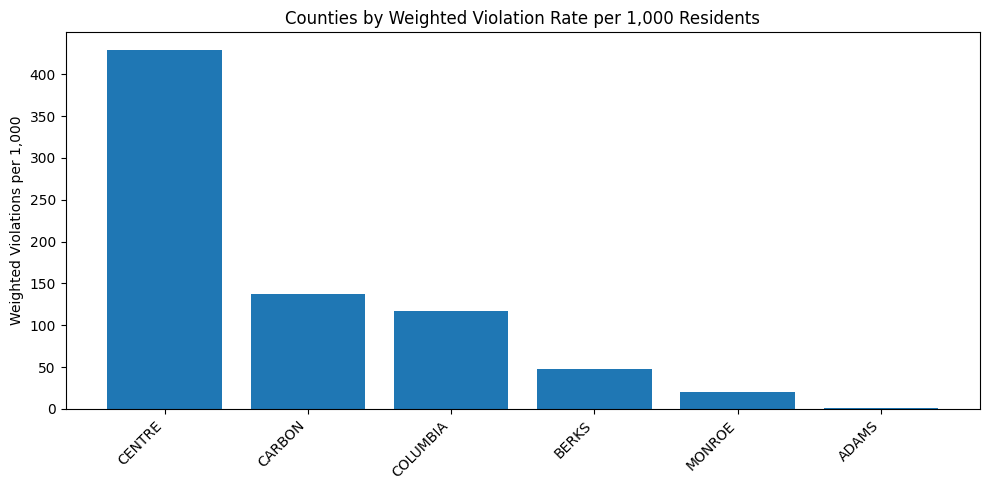

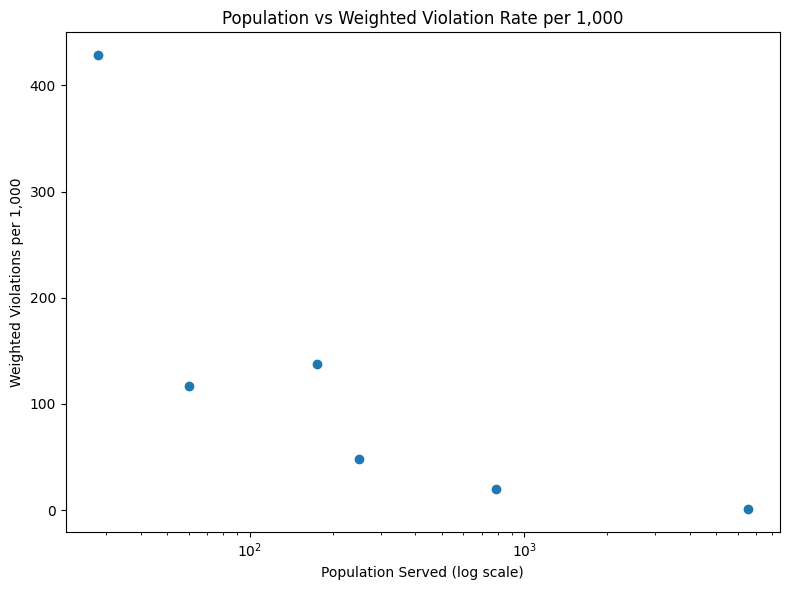

In [14]:
# Rebuild county_summary from df to avoid depending on prior variables

violation_rate_mean = df.groupby('County')['Violation_Rate'].mean().reset_index(name='Violation_Rate_Mean')
violation_quarters_sum = df.groupby('County')['Violation_Quarters_3yr'].sum().reset_index(name='Violation_Quarters_3yr_Sum')
pop_by_county = df.groupby('County')['Population'].sum().reset_index(name='Population_Impact')

named_agg = {}
if 'System_ID' in df.columns:
    named_agg['System_ID_Count'] = ('System_ID', 'count')
if 'Violation_Points_5yr' in df.columns:
    named_agg['Violation_Points_5yr'] = ('Violation_Points_5yr', 'sum')
if 'Uncorrected_Violation_Points' in df.columns:
    named_agg['Uncorrected_Violation_Points'] = ('Uncorrected_Violation_Points', 'sum')
if 'Persistent_Noncompliance' in df.columns:
    named_agg['Persistent_Noncompliance'] = ('Persistent_Noncompliance', 'sum')

if not named_agg:
    system_counts = df.groupby('County').size().reset_index(name='System_ID_Count')
else:
    system_counts = df.groupby('County').agg(**named_agg).reset_index()

county_summary = (
    system_counts
    .merge(violation_rate_mean, on='County', how='left')
    .merge(violation_quarters_sum, on='County', how='left')
    .merge(pop_by_county, on='County', how='left')
)

import pandas as _pd
county_summary['Population_Impact'] = county_summary['Population_Impact'].replace({0: _pd.NA})
county_summary['Weighted_Violation_Rate_per_1000'] = (
    county_summary['Violation_Quarters_3yr_Sum'] / county_summary['Population_Impact']
) * 1000

county_summary['Violation_Rate_Mean'] = county_summary['Violation_Rate_Mean'].round(3)
county_summary['Weighted_Violation_Rate_per_1000'] = county_summary['Weighted_Violation_Rate_per_1000'].round(3)
county_summary = county_summary.sort_values('Weighted_Violation_Rate_per_1000', ascending=False).reset_index(drop=True)

print(f"Counties with complete county-level data: {len(county_summary)}")
print(county_summary[['County', 'Violation_Rate_Mean', 'Weighted_Violation_Rate_per_1000']].to_string(index=False))

try:
    import plotly.express as px
    fig = px.bar(
        county_summary,
        x='County',
        y='Weighted_Violation_Rate_per_1000',
        title='Counties by Weighted Violation Rate per 1,000 Residents',
        labels={'Weighted_Violation_Rate_per_1000': 'Weighted Violations per 1,000'}
    )
    fig.update_layout(xaxis_tickangle=45)
    fig.show()

    fig2 = px.scatter(
        county_summary,
        x='Population_Impact',
        y='Weighted_Violation_Rate_per_1000',
        hover_name='County',
        title='Population vs Weighted Violation Rate per 1,000'
    )
    fig2.update_layout(xaxis_title='Population Served', yaxis_title='Weighted Violations per 1,000')
    fig2.show()
except Exception as e:
    print('Plotly not available, using Matplotlib instead:', e)
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    plt.bar(county_summary['County'], county_summary['Weighted_Violation_Rate_per_1000'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Weighted Violations per 1,000')
    plt.title('Counties by Weighted Violation Rate per 1,000 Residents')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(county_summary['Population_Impact'], county_summary['Weighted_Violation_Rate_per_1000'])
    plt.xscale('log')
    plt.xlabel('Population Served (log scale)')
    plt.ylabel('Weighted Violations per 1,000')
    plt.title('Population vs Weighted Violation Rate per 1,000')
    plt.tight_layout()
    plt.show()

#### Interpreting the County-Level Visualizations

**County ranking bar chart:**  
This chart ranks the counties with complete county-level data by population-weighted violation rate. It answers a simple question: where is violation exposure highest once population is taken into account? Counties near the top have more violations relative to the number of people served, so they stand out even if they do not have the largest number of systems.

**Population vs. weighted violation rate scatter plot:**  
This scatter plot shows how county population relates to weighted violation exposure.
- Smaller counties show much more spread, including the highest weighted rates in the dataset.
- Larger counties cluster closer to the bottom of the chart, which suggests lower per-capita exposure.
- The overall pattern matches the earlier correlation analysis. As population increases, weighted violation rates tend to fall.

Together, these plots show why population-adjusted measures matter. Raw counts alone would miss how differently violations affect counties of different sizes.

Counts per System_Type:
System_Type
NTNCWS    6
CWS       3
Name: count, dtype: int64
Plotly failed or is not available, falling back to Matplotlib: No module named 'plotly'


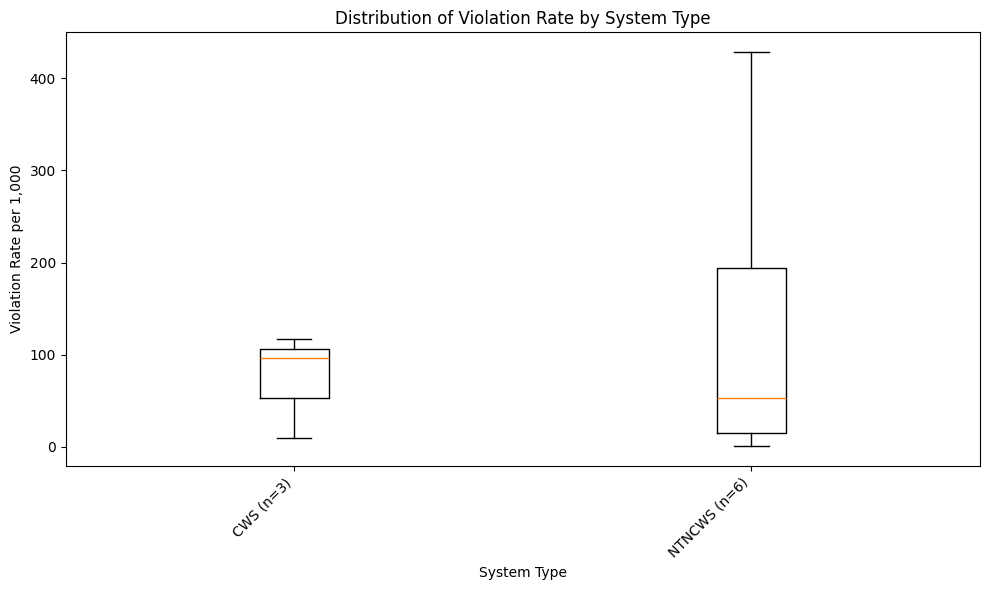


Top 10 systems by Violation_Rate:
   System_ID                     System_Name    County System_Type  \
4  PA4140902     PENNS VALLEY MEDICAL CENTER    CENTRE      NTNCWS   
6  PA3130978          PSP LEHIGHTON BARRACKS    CARBON      NTNCWS   
7  PA4190026          SUNSET RIDGE REHAB CTR  COLUMBIA         CWS   
0  PA3130049  CARBON COUNTY CORRECTIONAL FAC    CARBON         CWS   
5  PA2451002             POCONO SUMMIT PLAZA    MONROE      NTNCWS   
1  PA3060803       NEW MORGAN BORO UTIL AUTH     BERKS      NTNCWS   
2  PA2450124         NORTHRIDGE AT CAMELBACK    MONROE         CWS   
8  PA2451079  VILLAGE CTR AT MARSHALLS CREEK    MONROE      NTNCWS   
3  PA7010952      OUTLET SHOPS AT GETTYSBURG     ADAMS      NTNCWS   

   Population  Violation_Rate  
4          28      428.571429  
6          50      240.000000  
7          60      116.666667  
0         125       96.000000  
5         210       57.142857  
1         250       48.000000  
2         330        9.090909  
8       

In [18]:
# Additional visual: Violation_Rate distribution by System_Type (boxplot).

print('Counts per System_Type:')
if 'System_Type' in df.columns:
    print(df['System_Type'].value_counts())
else:
    print('No System_Type column found')

plot_df = df.dropna(subset=['Violation_Rate']).copy()

type_counts = plot_df['System_Type'].value_counts() if 'System_Type' in plot_df.columns else None
if type_counts is not None:
    labels_with_counts = {system_type: f"{system_type} (n={int(count)})" for system_type, count in type_counts.items()}
    medians = plot_df.groupby('System_Type')['Violation_Rate'].median().sort_values()
    category_order = medians.index.tolist()
else:
    labels_with_counts = {}
    category_order = None

try:
    import plotly.express as px
    if category_order is not None:
        fig = px.box(
            plot_df,
            x='System_Type',
            y='Violation_Rate',
            points='outliers',
            category_orders={'System_Type': category_order},
            title='Distribution of Violation Rate by System Type (per 1,000 residents)'
        )
    else:
        fig = px.box(
            plot_df,
            x='System_Type',
            y='Violation_Rate',
            points='outliers',
            title='Distribution of Violation Rate by System Type (per 1,000 residents)'
        )
    if labels_with_counts:
        fig.update_xaxes(
            ticktext=[labels_with_counts.get(value, value) for value in fig.data[0].x],
            tickvals=list(labels_with_counts.keys())
        )
    fig.update_layout(xaxis_title='System Type', yaxis_title='Violation Rate per 1,000', xaxis_tickangle=45)
    fig.show()
except Exception as e:
    print('Plotly failed or is not available, falling back to Matplotlib:', e)
    import matplotlib.pyplot as plt

    if 'System_Type' in plot_df.columns and not plot_df.empty:
        groups = [group['Violation_Rate'].values for _, group in plot_df.groupby('System_Type')]
        labels = [f"{name} (n={int(type_counts.get(name, 0))})" for name, group in plot_df.groupby('System_Type')]
        plt.figure(figsize=(10, 6))
        plt.boxplot(groups, tick_labels=labels, showfliers=False)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('System Type')
        plt.ylabel('Violation Rate per 1,000')
        plt.title('Distribution of Violation Rate by System Type')
        plt.tight_layout()
        plt.show()
    else:
        print('Not enough data to plot System_Type distributions')

print('\nTop 10 systems by Violation_Rate:')
print(
    df[['System_ID', 'System_Name', 'County', 'System_Type', 'Population', 'Violation_Rate']]
    .dropna(subset=['Violation_Rate'])
    .sort_values('Violation_Rate', ascending=False)
    .head(10)
)

### System-Level Violation Rate Distribution by System Type

This comparison shows how violation rates vary across system types and how much overlap exists between them.

#### What the Boxplot Shows

The boxplot compares violation rate distributions across system types (`NTNCWS` vs. `CWS`).

**NTNCWS (6 systems):**  
The median is 52.6 per 1,000. The middle 50% of values spans roughly 15 to 194, which shows substantial variability. Several systems sit far above the rest, including one extreme value above 400.

**CWS (3 systems):**  
The median is 96.0 per 1,000, slightly higher than the NTNCWS median. The distribution is narrower, which suggests less variation across the small number of community systems in the sample.

**What this means:**  
Even though the medians differ, the two distributions overlap heavily and the sample is very small. That is why the Kruskal-Wallis test does not show a statistically significant difference. The most extreme values appear in very small systems, where per-capita rates can spike quickly.

**Terminology:** `NTNCWS` means Non-Transient Non-Community Water System, such as a school or workplace. `CWS` means Community Water System, which primarily serves residents.

---

## Predictive Modeling: County Risk Classification

This section shifts from explanation to a small prediction exercise: can a county-level model separate relatively higher-risk counties from lower-risk ones?

### Data Limitation

The dataset contains only 6 counties with sufficient information for county-level modeling. Because the sample is so small, the predictive results should be treated as a demonstration of method rather than a production-ready model.

### Why I used a percentile-based risk label

I define **high-risk counties** as those in the **top 20% of county-level weighted violation rates**. A percentile threshold works better than a fixed cutoff here because the county sample is small and skewed, and it preserves enough positive cases for the model to learn a pattern.

### Modeling objective

- Build a binary classifier (`high_risk_county`: 1/0) from county-level aggregates.
- Evaluate performance with precision, recall, F1, and a confusion matrix.
- Keep the model interpretable so the results are easy to explain to a non-technical reader.

### Link to earlier findings

This modeling setup follows directly from earlier results in the notebook:
- Population size is strongly associated with violation outcomes.
- System type alone does not separate the groups well.
- County-level weighted exposure metrics are more informative than raw counts for prioritization.

In [16]:
# Predictive setup: create county-level percentile risk label and inspect class balance
import numpy as np
import pandas as pd

if 'df' not in globals() or df is None:
    df = pd.read_csv('Drinking_Water_Violations.csv')

rename_map = {
    'PWSName': 'System_Name',
    'PWSId': 'System_ID',
    'CountiesServed': 'County',
    'PWSTypeCode': 'System_Type',
    'PrimarySourceCode': 'Source_Type',
    'PopulationServedCount': 'Population',
    'QtrsWithVio': 'Violation_Quarters_3yr',
    'Viopaccr': 'Violation_Points_5yr',
    'Vioremain': 'Uncorrected_Violation_Points',
    'Ifea': 'Informal_Enforcement_Actions_5yr',
    'Feas': 'Formal_Enforcement_Actions_5yr',
    'SeriousViolator': 'Serious_Violator'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

q_col = 'Violation_Quarters_3yr' if 'Violation_Quarters_3yr' in df.columns else 'QtrsWithVio'
p_col = 'Population' if 'Population' in df.columns else 'PopulationServedCount'
county_col = 'County' if 'County' in df.columns else 'CountiesServed'

if q_col not in df.columns or p_col not in df.columns or county_col not in df.columns:
    raise ValueError('Missing required columns for county-level risk setup')

work_df = df.copy()
work_df[q_col] = pd.to_numeric(work_df[q_col], errors='coerce')
work_df[p_col] = pd.to_numeric(work_df[p_col], errors='coerce')
work_df = work_df.dropna(subset=[county_col, q_col, p_col]).copy()

county_df = work_df.groupby(county_col, as_index=False).agg(
    Total_Violations_3yr=(q_col, 'sum'),
    Total_Population=(p_col, 'sum'),
    System_Count=('System_ID', 'count') if 'System_ID' in work_df.columns else (county_col, 'size')
)

county_df = county_df[county_df['Total_Population'] > 0].copy()
county_df['Weighted_Violation_Rate_per_1000'] = (
    county_df['Total_Violations_3yr'] / county_df['Total_Population']
) * 1000

county_df = county_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Weighted_Violation_Rate_per_1000']).copy()

risk_quantile = 0.80  # top 20% of counties treated as high risk
risk_cutoff = county_df['Weighted_Violation_Rate_per_1000'].quantile(risk_quantile)
county_df['high_risk_county'] = (county_df['Weighted_Violation_Rate_per_1000'] >= risk_cutoff).astype(int)

print(f'Counties available for modeling: {len(county_df)}')
print(f'County risk cutoff (q={risk_quantile:.2f}): {risk_cutoff:.3f}')
print('Class counts:')
print(county_df['high_risk_county'].value_counts().rename(index={0: 'low_risk_county', 1: 'high_risk_county'}).to_string())
print('Class proportions:')
print((county_df['high_risk_county'].value_counts(normalize=True) * 100).round(1).rename(index={0: 'low_risk_county', 1: 'high_risk_county'}).astype(str) + '%')

print('\nExample high-risk counties:')
display(
    county_df.loc[county_df['high_risk_county'] == 1, [county_col, 'System_Count', 'Total_Population', 'Weighted_Violation_Rate_per_1000']]
    .sort_values('Weighted_Violation_Rate_per_1000', ascending=False)
    .head(10)
)

Counties available for modeling: 6
County risk cutoff (q=0.80): 137.143
Class counts:
high_risk_county
low_risk_county     4
high_risk_county    2
Class proportions:
high_risk_county
low_risk_county     66.7%
high_risk_county    33.3%
Name: proportion, dtype: object

Example high-risk counties:


,County,System_Count,Total_Population,Weighted_Violation_Rate_per_1000
3,CENTRE,1,28,428.571429
2,CARBON,2,175,137.142857


### Baseline Model: Logistic Regression with Leave-One-Out Cross-Validation

With only 6 counties, a standard train/test split (e.g., 70/30) would leave just 4 counties for training and 2 for testing, which is too unstable and noisy. Instead, I use Leave-One-Out (LOO) Cross-Validation:

1. Fit the model 6 times, each time leaving out one county.
2. Predict on the left-out county using that fold's trained model.
3. Collect all 6 out-of-sample predictions and evaluate against true labels.

This approach maximizes data usage while giving honest out-of-sample estimates.

**Model Details:**
- Algorithm: Logistic Regression (binary classifier)
- Features: Total Population, System Count, Total Violations (3-year)
- Class Weighting: `balanced` to account for 2 high-risk vs. 4 low-risk counties
- Feature Scaling: StandardScaler (required for logistic regression coefficient interpretation)

In [17]:
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, auc
import numpy as np
import pandas as pd

# Prepare X and y
feature_cols = ['Total_Population', 'System_Count', 'Total_Violations_3yr']
X = county_df[feature_cols].values
y = county_df['high_risk_county'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class distribution: {np.bincount(y)} (0: low_risk, 1: high_risk)")

# Leave-One-Out Cross-Validation
loo = LeaveOneOut()
scaler = StandardScaler()
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

y_pred_proba_loo = np.zeros(len(y))
y_pred_loo = np.zeros(len(y))

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train = y[train_idx]
    
    # Standardize features
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Fit model
    model.fit(X_train_scaled, y_train)
    
    # Predict on left-out county
    y_pred_proba_loo[test_idx] = model.predict_proba(X_test_scaled)[:, 1]
    y_pred_loo[test_idx] = model.predict(X_test_scaled)

# Evaluate
cm = confusion_matrix(y, y_pred_loo)
precision = precision_score(y, y_pred_loo, zero_division=0)
recall = recall_score(y, y_pred_loo, zero_division=0)
f1 = f1_score(y, y_pred_loo, zero_division=0)

# Precision-Recall AUC
precision_vals, recall_vals, _ = precision_recall_curve(y, y_pred_proba_loo)
pr_auc = auc(recall_vals, precision_vals)

print('\n=== Leave-One-Out Cross-Validation Results ===')
print(f'\nConfusion Matrix:\n{cm}')
print(f'\nTrue Negatives (TN): {cm[0, 0]}, False Positives (FP): {cm[0, 1]}')
print(f'False Negatives (FN): {cm[1, 0]}, True Positives (TP): {cm[1, 1]}')
print(f'\nPrecision (TP / (TP+FP)): {precision:.3f}')
print(f'Recall (TP / (TP+FN)): {recall:.3f}')
print(f'F1 Score: {f1:.3f}')
print(f'PR-AUC: {pr_auc:.3f}')

# Show county-by-county predictions
results_df = county_df.copy()
results_df['Predicted_Probability'] = y_pred_proba_loo
results_df['Predicted_Label'] = y_pred_loo
results_df['True_Label'] = y

print('\n=== County-by-County Predictions ===')
print(results_df[[county_col, 'Weighted_Violation_Rate_per_1000', 'Predicted_Probability', 'True_Label', 'Predicted_Label']].to_string())

Feature matrix shape: (6, 3)
Target shape: (6,)
Class distribution: [4 2] (0: low_risk, 1: high_risk)

=== Leave-One-Out Cross-Validation Results ===

Confusion Matrix:
[[2 2]
 [1 1]]

True Negatives (TN): 2, False Positives (FP): 2
False Negatives (FN): 1, True Positives (TP): 1

Precision (TP / (TP+FP)): 0.333
Recall (TP / (TP+FN)): 0.500
F1 Score: 0.400
PR-AUC: 0.287

=== County-by-County Predictions ===
     County  Weighted_Violation_Rate_per_1000  Predicted_Probability  True_Label  Predicted_Label
0     ADAMS                          0.615385           9.889065e-08           0              0.0
1     BERKS                         48.000000           5.743889e-01           0              1.0
2    CARBON                        137.142857           6.955577e-01           1              1.0
3    CENTRE                        428.571429           3.084975e-01           1              0.0
4  COLUMBIA                        116.666667           4.381410e-01           0              0.0
5

#### What These Numbers Mean

The **confusion matrix** shows how often the model got predictions right and wrong:
- **TN (True Negatives): 2** – Model said "low risk," and it was correct 2 times.
- **FP (False Positives): 2** – Model said "high risk," but it was actually low risk 2 times (false alarms).
- **FN (False Negatives): 1** – Model said "low risk," but it was actually high risk 1 time (missed a real problem).
- **TP (True Positives): 1** – Model said "high risk," and it was correct 1 time.

**Key metrics:**
- **Precision (0.333):** Out of the 3 counties the model flagged as "high-risk," only 1 was actually high-risk. So 33% of alarms are correct. The model is being too aggressive.
- **Recall (0.500):** Out of the 2 truly high-risk counties, the model caught only 1. It's missing 50% of real problems.
- **F1 (0.400):** A balanced score combining precision and recall. Lower values mean the model is struggling, which makes sense with only 6 counties.
- **PR-AUC (0.287):** Measures overall ranking ability. Closer to 1.0 is better; 0.5 is random. At 0.287, the model is below average, but this is expected with tiny data.

**Bottom line:** The model is okay at **ranking** counties (identifying which are riskier), but shouldn't be trusted as a precise classifier alone. Always combine with expert judgment.

### Threshold Tuning: Precision vs. Recall Tradeoff

The default logistic regression threshold is 0.5, which means the model predicts "high-risk" when the estimated probability is at least 0.5. Changing that threshold changes the balance between precision and recall.

- **Higher threshold (for example, 0.7):** Higher precision and lower recall. The model flags fewer counties, but it does so more conservatively.
- **Lower threshold (for example, 0.3):** Lower precision and higher recall. The model casts a wider net and catches more true high-risk counties, but it also creates more false alarms.

The chart below shows how that tradeoff changes across thresholds. In practice, the threshold choice depends on whether you care more about minimizing false alarms or minimizing missed high-risk cases.

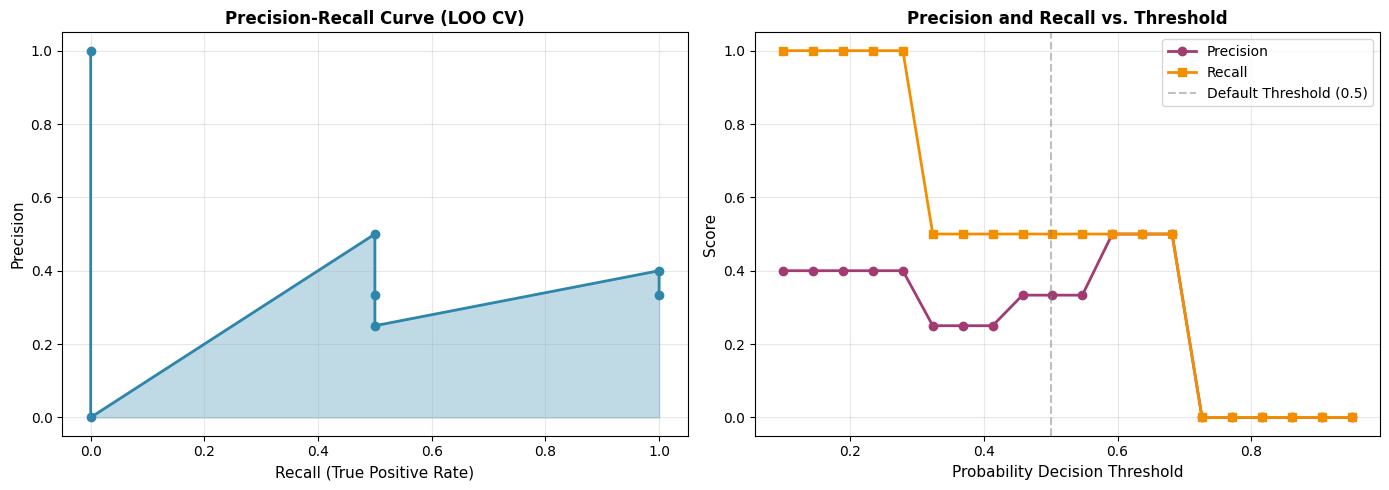

=== Threshold Comparison ===

Threshold | Precision | Recall | Counties Flagged
--------------------------------------------------
  0.3    |  0.400   |  1.000  |      5
  0.4    |  0.250   |  0.500  |      4
  0.5    |  0.333   |  0.500  |      3
  0.6    |  0.500   |  0.500  |      2
  0.7    |  0.000   |  0.000  |      1


In [19]:
from pathlib import Path
import matplotlib.pyplot as plt

precision_vals, recall_vals, thresholds = precision_recall_curve(y, y_pred_proba_loo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(recall_vals, precision_vals, marker='o', linewidth=2, markersize=6, color='#2E86AB')
ax1.fill_between(recall_vals, precision_vals, alpha=0.3, color='#2E86AB')
ax1.set_xlabel('Recall (True Positive Rate)', fontsize=11)
ax1.set_ylabel('Precision', fontsize=11)
ax1.set_title('Precision-Recall Curve (LOO CV)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-0.05, 1.05])
ax1.set_ylim([-0.05, 1.05])

thresholds_to_plot = np.linspace(0.1, 0.95, 20)
precision_at_threshold = []
recall_at_threshold = []

for thresh in thresholds_to_plot:
    y_pred_at_thresh = (y_pred_proba_loo >= thresh).astype(int)
    if y_pred_at_thresh.sum() > 0:
        prec = precision_score(y, y_pred_at_thresh, zero_division=0)
        rec = recall_score(y, y_pred_at_thresh, zero_division=0)
    else:
        prec, rec = 0, 0
    precision_at_threshold.append(prec)
    recall_at_threshold.append(rec)

ax2.plot(thresholds_to_plot, precision_at_threshold, marker='o', label='Precision', linewidth=2, color='#A23B72')
ax2.plot(thresholds_to_plot, recall_at_threshold, marker='s', label='Recall', linewidth=2, color='#F18F01')
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default Threshold (0.5)')
ax2.set_xlabel('Probability Decision Threshold', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Precision and Recall vs. Threshold', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-0.05, 1.05])

plt.tight_layout()
output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Threshold Comparison ===\n')
print('Threshold | Precision | Recall | Counties Flagged')
print('-' * 50)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_at_thresh = (y_pred_proba_loo >= thresh).astype(int)
    n_flagged = y_pred_at_thresh.sum()
    if n_flagged > 0:
        prec = precision_score(y, y_pred_at_thresh, zero_division=0)
        rec = recall_score(y, y_pred_at_thresh, zero_division=0)
    else:
        prec, rec = 0, 0
    print(f'  {thresh:.1f}    |  {prec:.3f}   |  {rec:.3f}  |      {int(n_flagged)}')

#### Reading the Precision-Recall Charts

**Left chart (precision-recall curve):**
- The curve shows the tradeoff between catching more high-risk counties and keeping the flagged set accurate.
- A curve that stays high would indicate strong model performance. This one sits lower, which is expected with such a small sample.
- The area under the curve (`PR-AUC = 0.287`) summarizes ranking quality across thresholds.

**Right chart (precision and recall vs. threshold):**
- The **orange line** shows recall, or the share of true high-risk counties the model captures.
- The **purple line** shows precision, or how many flagged counties are actually high-risk.
- At a low threshold like `0.3`, recall is high but false alarms increase.
- At a higher threshold like `0.7`, the model becomes too conservative and misses the high-risk counties.

**Bottom line:** There is no perfect threshold in this dataset. The threshold mainly controls whether the model behaves more cautiously or more aggressively.

### Model Interpretation & Feature Importance

This section explains which features influence the model most and how that logic maps onto the county rankings.

In [20]:
# Train final model on all data to extract feature coefficients
scaler_final = StandardScaler()
model_final = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

X_scaled = scaler_final.fit_transform(X)
model_final.fit(X_scaled, y)

coefficients = model_final.coef_[0]
intercept = model_final.intercept_[0]

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print('=== Feature Importance (Logistic Regression Coefficients) ===\n')
print(feature_importance_df[['Feature', 'Coefficient']].to_string(index=False))
print(f'\nIntercept: {intercept:.4f}')

print('\n=== Interpretation ===')
for _, row in feature_importance_df.iterrows():
    sign = 'INCREASES' if row['Coefficient'] > 0 else 'DECREASES'
    magnitude = 'strong' if np.abs(row['Coefficient']) > 0.5 else 'moderate' if np.abs(row['Coefficient']) > 0.2 else 'weak'
    print(f"{row['Feature']:30s} ({sign:10s} risk, {magnitude:8s}): {row['Coefficient']:+.4f}")

print('\n=== County-by-County Risk Assessment ===\n')
results_summary = results_df[[
    county_col,
    'Total_Population',
    'System_Count',
    'Total_Violations_3yr',
    'Weighted_Violation_Rate_per_1000',
    'Predicted_Probability',
    'True_Label'
]].copy()
results_summary['Risk_Flag'] = results_summary['Predicted_Probability'].apply(lambda probability: 'HIGH' if probability >= 0.5 else 'LOW')
results_summary = results_summary.sort_values('Predicted_Probability', ascending=False)

print(results_summary.to_string(index=False))

print('\n=== Screening Summary ===\n')
high_probability_counties = results_summary[results_summary['Risk_Flag'] == 'HIGH'][county_col].tolist()
low_probability_counties = results_summary[results_summary['Risk_Flag'] == 'LOW'][county_col].tolist()

print(f'Counties above the 0.5 probability threshold: {", ".join(high_probability_counties) if high_probability_counties else "None"}')
print(f'Counties below the 0.5 probability threshold: {", ".join(low_probability_counties) if low_probability_counties else "None"}')
print('\nInterpretation note:')
print('Read this output as a ranking aid, not as a standalone decision rule.')
print('With only 6 counties, the probabilities are useful for comparison but not stable enough to treat as firm forecasts.')

=== Feature Importance (Logistic Regression Coefficients) ===

             Feature  Coefficient
Total_Violations_3yr     0.810523
    Total_Population    -0.377047
        System_Count    -0.331791

Intercept: -0.2502

=== Interpretation ===
Total_Violations_3yr           (INCREASES  risk, strong  ): +0.8105
Total_Population               (DECREASES  risk, moderate): -0.3770
System_Count                   (DECREASES  risk, moderate): -0.3318

=== County-by-County Risk Assessment ===

  County  Total_Population  System_Count  Total_Violations_3yr  Weighted_Violation_Rate_per_1000  Predicted_Probability  True_Label Risk_Flag
  MONROE               790             3                    16                         20.253165           8.902227e-01           0      HIGH
  CARBON               175             2                    24                        137.142857           6.955577e-01           1      HIGH
   BERKS               250             1                    12                      

#### What the Feature Importance Tells Us

The coefficients show which factors push the model toward a higher-risk prediction.

- **Total_Violations_3yr (+0.81, strong):** This is the strongest predictor. More violations increase predicted risk.
- **Total_Population (-0.38, moderate):** Larger counties tend to look lower risk after adjustment because the same number of violations is spread across more people.
- **System_Count (-0.33, moderate):** Counties with more systems tend to look somewhat lower risk, which may reflect a more distributed system base.

**Why this matters:**
1. The model is interpretable. Its logic follows the same patterns seen in the earlier analysis.
2. The ranking is easier to defend because the strongest driver is the county's underlying violation burden.

**County-level interpretation:**
- **Monroe (89.0% probability):** Ranked highest because its violation count is large relative to the population served.
- **Carbon (69.6% probability):** Correctly identified as high-risk by the model.
- **Berks (57.4% probability):** Ranked high, but this turns into a false positive under the default threshold.
- **Centre (30.8% probability):** Missed by the model, likely because its extremely small population creates a pattern that the simple feature set does not capture well.

**Takeaway:** The ranking is more useful than the hard cutoff. It helps separate counties that deserve closer attention, even when the classification itself is imperfect.

### Model Calibration & Limitations

With only 6 counties, the predicted probabilities should be interpreted as **relative risk rankings** rather than true calibrated probabilities. Below, we check calibration using a simple scatter plot and Brier score.

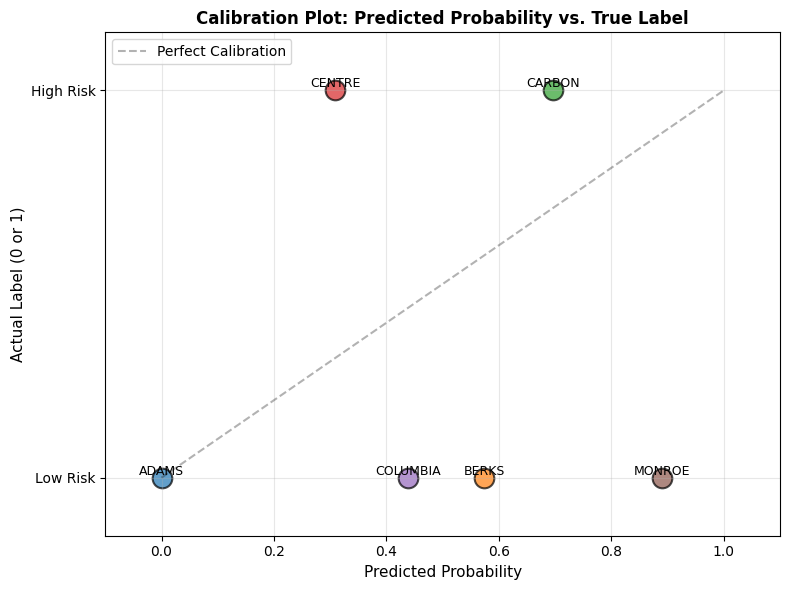

=== Calibration and Reliability ===

Brier Score: 0.314
(Lower is better; 0 = perfect, 0.5 = useless, 1 = worst)
Assessment: Moderate calibration

=== Key Limitations ===

1. SMALL SAMPLE SIZE (6 counties)
   → Predicted probabilities are rough estimates, not statistically reliable
   → Use rankings rather than absolute probabilities

2. IMBALANCED CLASSES (4 low / 2 high)
   → Model is more useful for ranking than for precise calibration
   → With more data, the probability estimates could change substantially

3. LIMITED FEATURES
   → Only aggregated county-level metrics are included here
   → Missing severity, violation type, enforcement history, and time trends

=== How to Read the Predictions ===

✓ DO:   Use the model to compare counties relative to one another
✓ DO:   Treat the ranking as one input alongside domain context
✓ DO:   Focus more on ordering than on the exact probability values

✗ DON'T: Treat predicted probability as a literal "% chance" value
✗ DON'T: Use the model

In [21]:
from pathlib import Path
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y, y_pred_proba_loo)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for idx, row in results_df.iterrows():
    prob = y_pred_proba_loo[idx]
    label = y[idx]
    ax.scatter(prob, label, s=200, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax.annotate(row[county_col], (prob, label), fontsize=9, ha='center', va='bottom')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Calibration')
ax.set_xlabel('Predicted Probability', fontsize=11)
ax.set_ylabel('Actual Label (0 or 1)', fontsize=11)
ax.set_title('Calibration Plot: Predicted Probability vs. True Label', fontsize=12, fontweight='bold')
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.15, 1.15])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low Risk', 'High Risk'])
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Calibration and Reliability ===\n')
print(f'Brier Score: {brier:.3f}')
print('(Lower is better; 0 = perfect, 0.5 = useless, 1 = worst)')

if brier < 0.25:
    quality = 'Good calibration'
elif brier < 0.5:
    quality = 'Moderate calibration'
else:
    quality = 'Poor calibration'
print(f'Assessment: {quality}\n')

print('=== Key Limitations ===\n')
print('1. SMALL SAMPLE SIZE (6 counties)')
print('   → Predicted probabilities are rough estimates, not statistically reliable')
print('   → Use rankings rather than absolute probabilities')
print('')
print('2. IMBALANCED CLASSES (4 low / 2 high)')
print('   → Model is more useful for ranking than for precise calibration')
print('   → With more data, the probability estimates could change substantially')
print('')
print('3. LIMITED FEATURES')
print('   → Only aggregated county-level metrics are included here')
print('   → Missing severity, violation type, enforcement history, and time trends')
print('')
print('=== How to Read the Predictions ===\n')
print('✓ DO:   Use the model to compare counties relative to one another')
print('✓ DO:   Treat the ranking as one input alongside domain context')
print('✓ DO:   Focus more on ordering than on the exact probability values')
print('')
print('✗ DON\'T: Treat predicted probability as a literal "% chance" value')
print('✗ DON\'T: Use the model alone as a final decision rule')
print('✗ DON\'T: Claim strong statistical certainty from 6 county observations')

#### Interpreting Calibration: Is the Model Honest About Its Confidence?

**Calibration plot interpretation:**
- Each dot represents one county.
- The **x-position** is the model's predicted probability, where `0` means very low predicted risk and `1` means very high predicted risk.
- The **y-position** is the true label, where `0` is low-risk and `1` is high-risk.
- If the dots lined up neatly with the diagonal reference line, the probabilities would be well calibrated.
- Instead, the dots are scattered. That tells us the probability estimates are not especially reliable, which is expected with only 6 counties.

**Brier score (0.314):**
- This measures average probability error. Lower is better.
- A score of `0.314` suggests moderate calibration. The model is not unusable, but it is not precise enough to treat the probabilities literally.

**Example reading:**
- Monroe is predicted near 89% but is actually low-risk. That is a large error.
- Carbon is predicted near 70% and is actually high-risk. That is a more reasonable fit.
- Centre is predicted near 31% but is actually high-risk. That is another large miss.

**Bottom line:** The probabilities are best read as rough relative rankings. They are useful for comparison, but not strong enough to interpret as true risk percentages.

---

## Conclusions

### What This Project Shows

This notebook demonstrates a full small-scale analytics workflow for an environmental compliance problem.

### Key Findings
1. **Population is the dominant factor** behind apparent violation rates. Small systems often look riskier because the denominator is so small.
2. **System type does not explain much on its own** in this dataset. The distributions overlap and the statistical test is not significant.
3. **Exposure-aware metrics change the story**. Population-weighted county rates highlight a different pattern than raw counts or simple averages.
4. **Predictive modeling is possible, but fragile**. With only 6 counties, the model is best used as a ranking exercise rather than a forecasting tool.

### Why the project matters
1. It shows how to combine cleaning, exploratory analysis, statistical testing, and modeling in one reproducible workflow.
2. It demonstrates careful interpretation of small-sample results instead of overstating certainty.
3. It emphasizes communication, not just computation, by translating technical output into plain language.

---

## Summary: Key Takeaways

**Core Findings:**

1. **Population is the dominant statistical driver.** Violation rates drop sharply as system size increases (`Spearman rho = -0.971`, `p < 0.0001`). Small systems often show inflated per-capita rates because the population denominator is very small.

2. **System type is not a strong predictor.** `NTNCWS` and `CWS` systems have overlapping violation rate distributions (`Kruskal-Wallis p = 0.796`), which suggests that system type alone explains little in this sample.

3. **Aggregation method matters.** A county's simple average violation rate can differ substantially from its population-weighted rate, which changes how counties compare to one another.

4. **Outliers deserve careful interpretation.** Some very small systems (`< 100` residents) have extreme rates ranging from `0.6` to `428` per 1,000, which could reflect unusual conditions, data quality issues, or denominator effects.

**Data Limitations:**

- Sample size is small (`9` systems with complete data and `6` counties for modeling).
- Temporal information is limited. The analysis captures a snapshot rather than a trend over time.
- Violation severity and type are not differentiated in the modeling setup.
- Predictive evaluation is statistically fragile because the county sample is so small.